# Figure 2 — Differential unproductive splicing across human tissues

Unproductive splicing is not uniform across the body: its overall level varies
several-fold between tissues, it tracks the expression of the NMD factor
*UPF3A*, and where an unproductive junction is used more, the host gene is
expressed less.

| Panel | What it shows |
|---|---|
| **a** | Percentage of junction reads that are unproductive, per sample, by tissue |
| **b** | Splicing-vs-expression correlation for every pair of tissues |
| **e** | *GABBR1* expression across tissues, high in brain where the unproductive junction is least used |

In [1]:
import os
import importlib

from matplotlib import pyplot as plt

import Figure2_plot_helpers
import Figure2_helpers
importlib.reload(Figure2_plot_helpers)
importlib.reload(Figure2_helpers)

from Figure2_plot_helpers import (plot_fig2a, plot_fig2b, plot_gene_boxplots,
                                  boxplot_legend, fig2b_legend, FIG2A_CENTRE_LEGEND)
from Figure2_helpers import run_all, load_plot_data, TEN_TISSUES_CLEAN, BOXPLOT_PALETTE

# Keep text as editable text in the vector output, not outlined shapes.
# svg.fonttype='none'  -> matplotlib emits <text> elements that name the font
#                         instead of converting each glyph to a <path>, so
#                         Inkscape opens them as editable text objects.
# pdf.fonttype=42      -> embeds TrueType rather than Type 3, which keeps text
#                         selectable and editable in PDF editors too.
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print('panels will be written to', PLOTS_DIR)


def save_panel(name, dpi=300):
    """Clear every rasterization flag on the current figure, then save it.

    The plot helpers pass rasterized=True to their scatter/strip layers. Walking
    fig.findobj() and calling set_rasterized(False) turns that off without
    editing Figure2_plot_helpers.py, so the PDF and SVG hold real vector paths.
    """
    fig = plt.gcf()
    for artist in fig.findobj():
        if hasattr(artist, 'set_rasterized'):
            try:
                artist.set_rasterized(False)
            except Exception:
                pass
    for ax in fig.axes:
        ax.set_rasterization_zorder(None)

    for ext in ['png', 'pdf', 'svg']:
        fig.savefig(f'{PLOTS_DIR}/{name}.{ext}', dpi=dpi, bbox_inches='tight')
    print('wrote', f'{PLOTS_DIR}/{name}.[png|pdf|svg]')
    return fig

panels will be written to plots


In [2]:
# Fast path: re-plot straight from the pickles written by run_all().
# Uncomment this cell and skip the next one.

# data = load_plot_data('figure_data')

# fig2a_panels        = data['fig2a_panels']
# fig2a_tissue_names  = data['fig2a_tissue_names']
# fig2b_series        = data['fig2b_series']
# fig2b_source_data   = data['fig2b_source_data']
# fig2e_boxplot_df    = data['fig2e_boxplot_df']
# fig2e_boxplot_stats = data['fig2e_boxplot_stats']

In [3]:
# Full data pipeline: reads the GTEx leafcutter2 noise tables, the GTEx TPM
# table and the pairwise splicing-vs-expression comparisons, computes the
# Fig. 2e sample sizes and Wilcoxon signed-rank test and the Fig. 2b per-point
# statistics, then pickles every plot-ready variable into figure_data/ and
# writes figure_data/fig2b_source_data.tsv (Supplementary Table 3).
# This is the only heavy cell.

data = run_all('figure_data')

fig2a_panels        = data['fig2a_panels']
fig2a_tissue_names  = data['fig2a_tissue_names']
fig2b_series        = data['fig2b_series']
fig2b_source_data   = data['fig2b_source_data']
fig2e_boxplot_df    = data['fig2e_boxplot_df']
fig2e_boxplot_stats = data['fig2e_boxplot_stats']

102305it [00:02, 37682.47it/s]
100393it [00:03, 28784.87it/s]
103296it [00:05, 18118.95it/s]
106105it [00:16, 6384.04it/s]
98137it [00:18, 5217.31it/s]
128328it [00:17, 7464.25it/s]
109912it [00:24, 4516.97it/s]
100056it [00:04, 20819.37it/s]
95357it [00:23, 4072.83it/s]
114311it [00:20, 5633.85it/s]
100389it [00:05, 18833.82it/s]
88952it [00:05, 15752.91it/s]
101510it [00:06, 16223.90it/s]
89607it [00:19, 4610.84it/s]
108774it [00:19, 5514.46it/s]
97921it [00:04, 19612.02it/s]
102250it [00:10, 9488.03it/s] 
105312it [00:05, 19779.10it/s]
107100it [00:18, 5852.17it/s]
110122it [00:08, 13674.36it/s]
103219it [00:06, 15927.05it/s]
98231it [00:05, 19174.90it/s]
102123it [00:11, 8543.17it/s] 
101029it [00:04, 21160.52it/s]
105032it [00:05, 17553.77it/s]
101166it [00:02, 44421.82it/s]
109170it [00:03, 30667.38it/s]
93397it [00:06, 14441.75it/s]
102033it [00:03, 26437.53it/s]
103113it [00:04, 23253.77it/s]
104736it [00:06, 15988.73it/s]
109601it [00:12, 9062.89it/s] 
93881it [00:05, 18151.95

### Fig. 2a

Percent of junction reads that are classified as unproductive for each sample,
grouped according to GTEx tissue type.

wrote plots/fig2a.[png|pdf|svg]


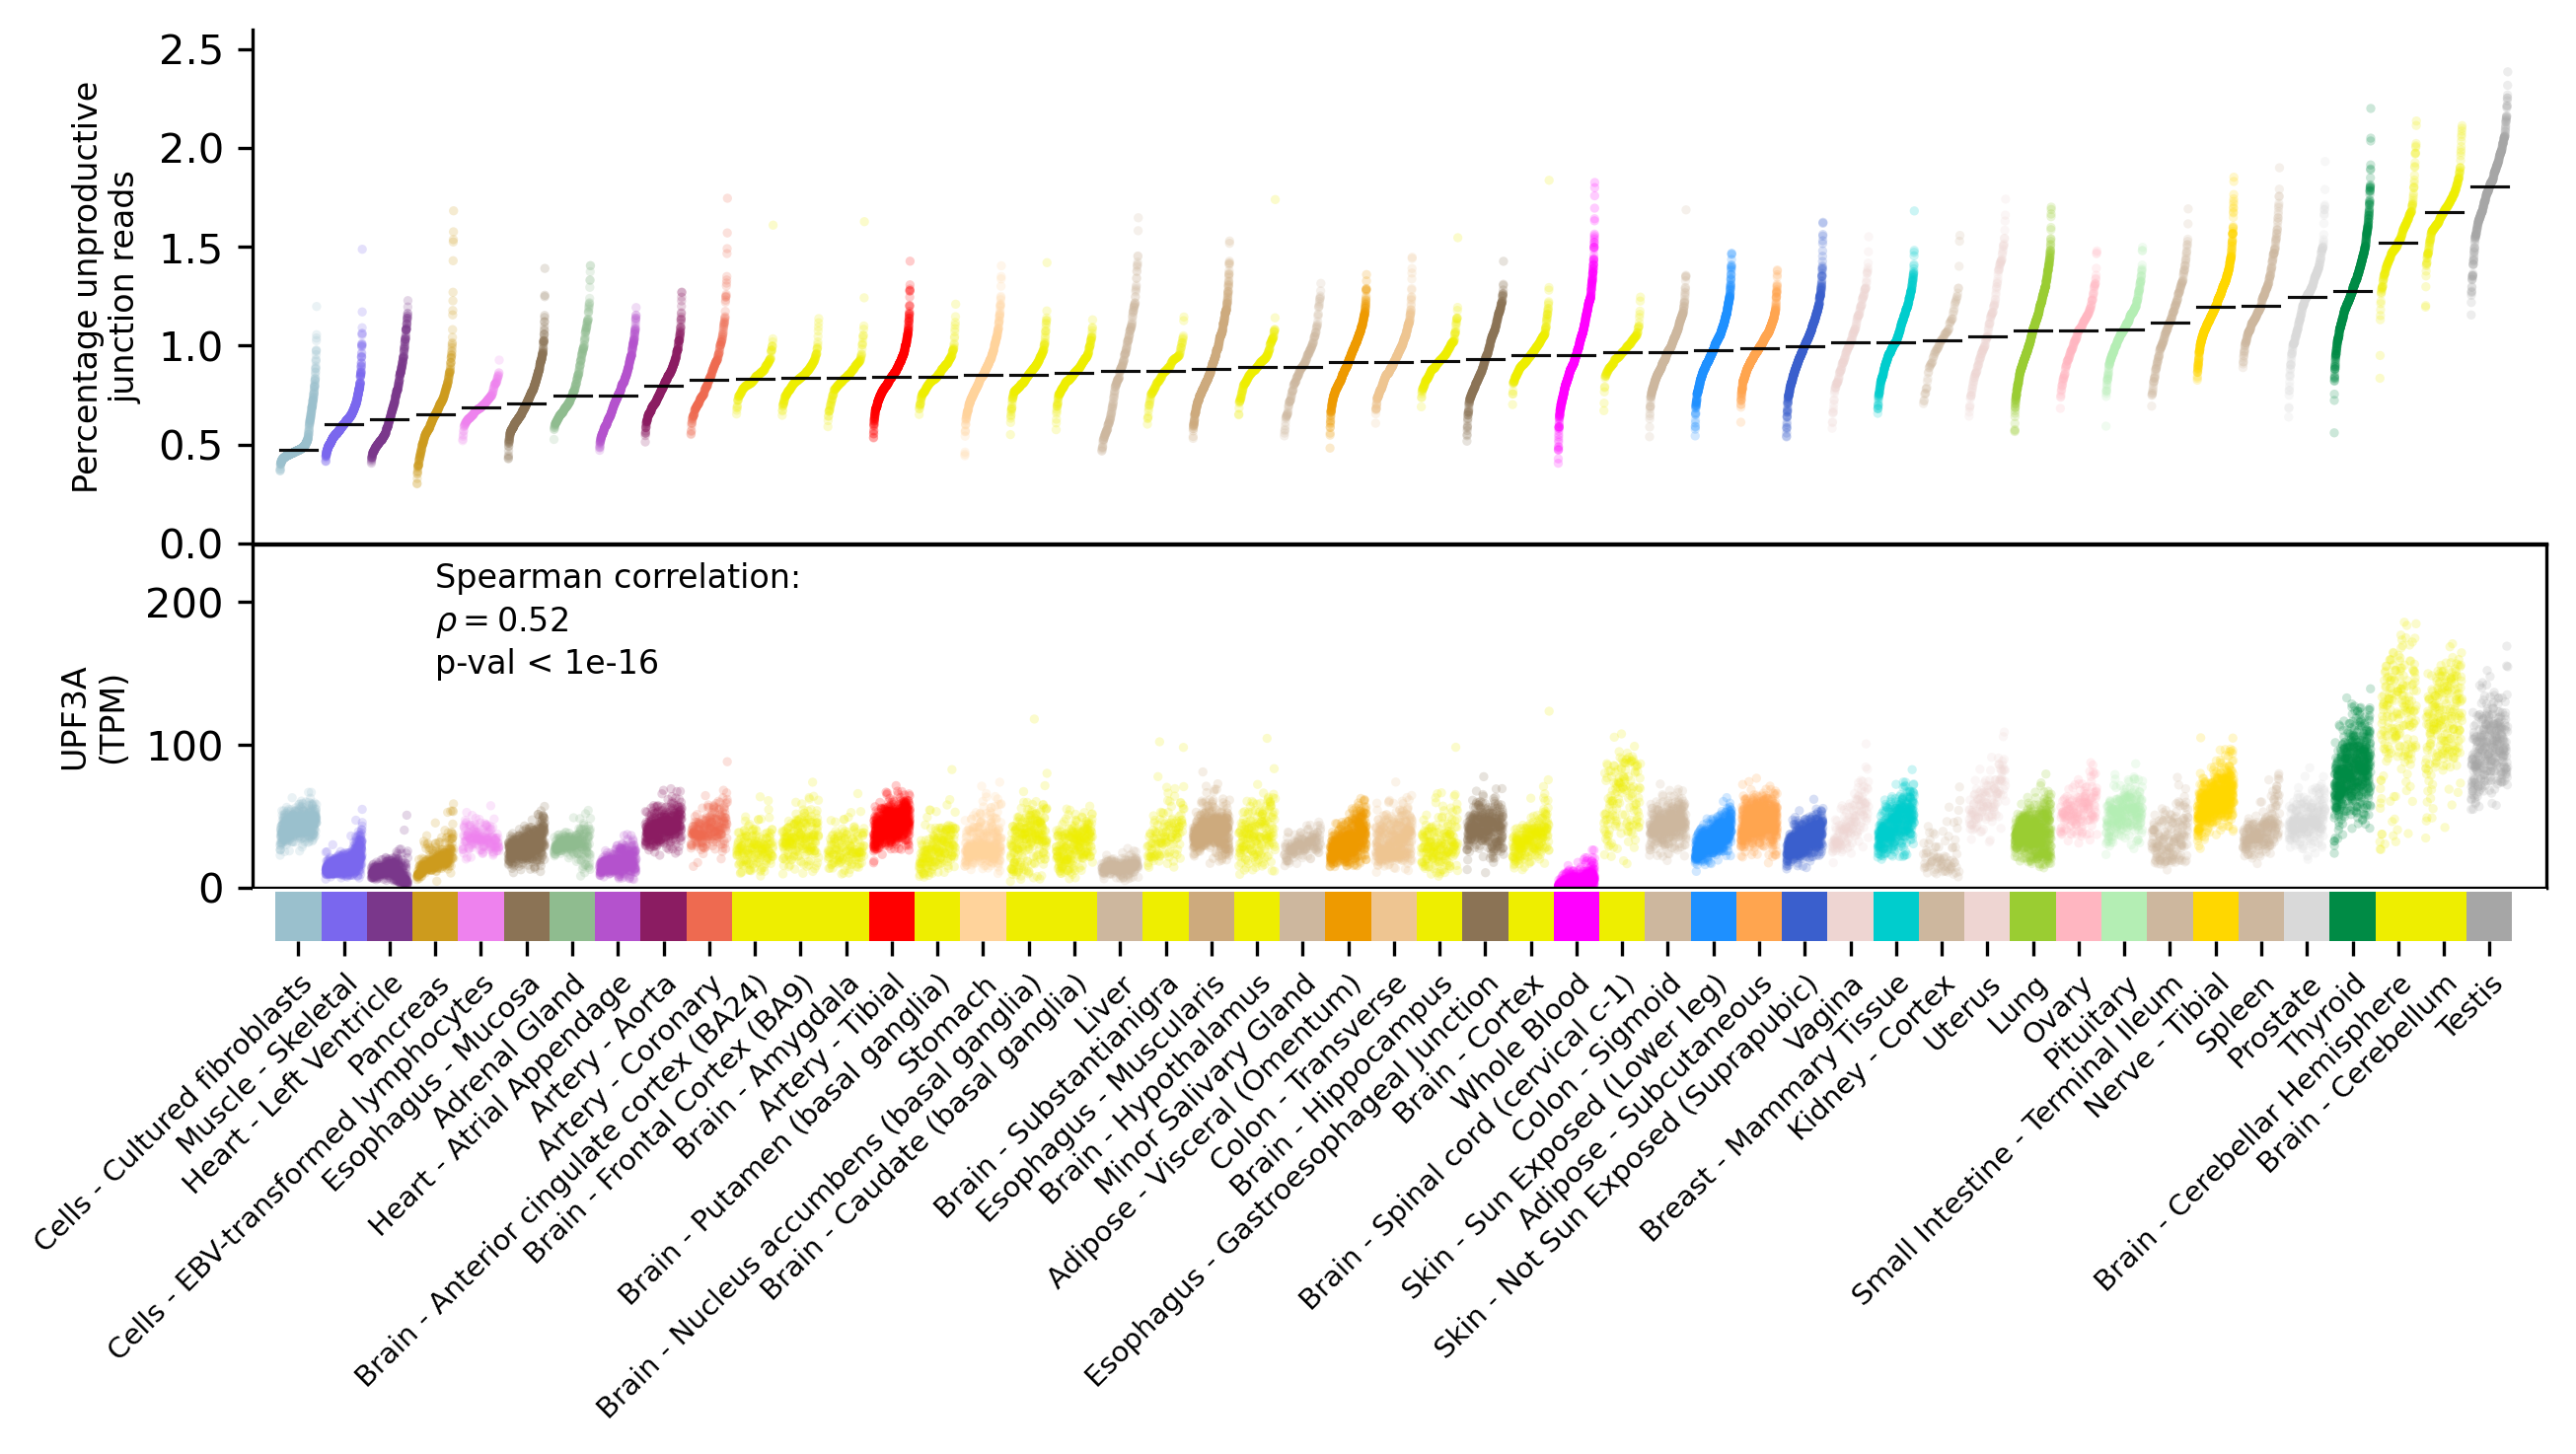

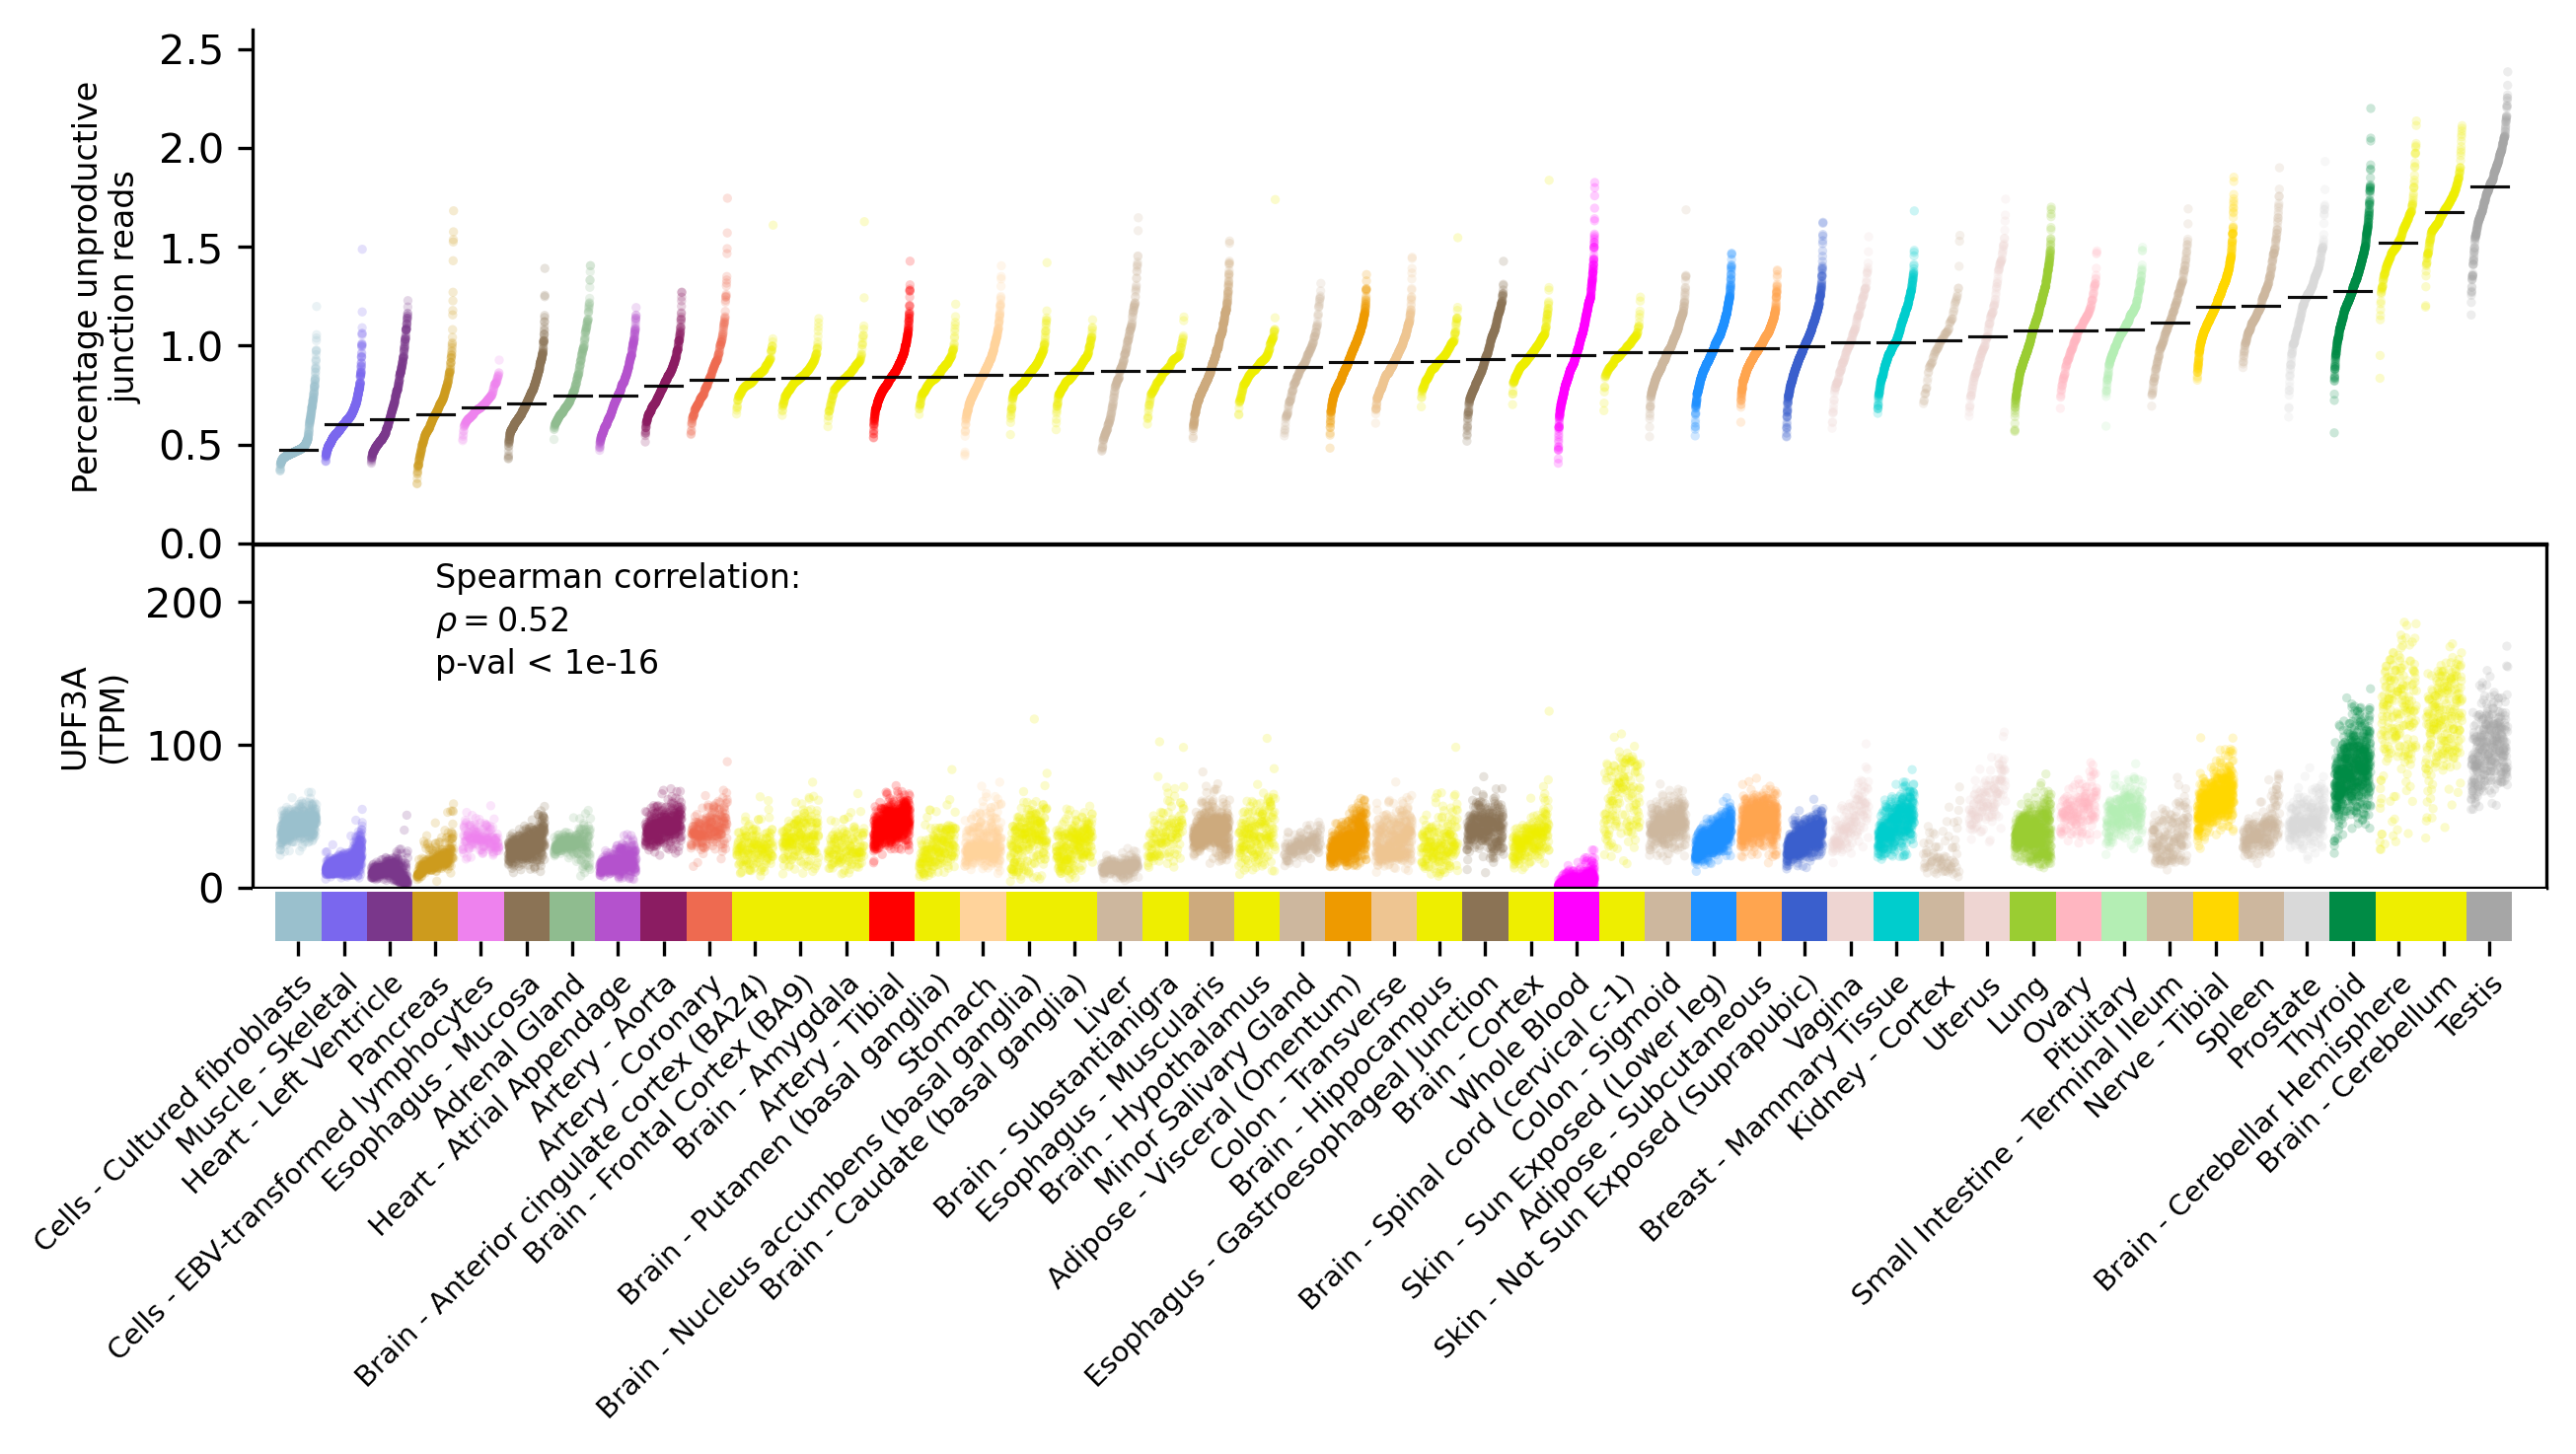

In [4]:
# Fig. 2a

plot_fig2a(fig2a_panels, fig2a_tissue_names)
save_panel('fig2a', dpi=300)

### Fig. 2b

Scatter plot showing the two-sided Spearman's correlation between delta PSI and
differential gene expression Z-scores for tissue pairs (x-axis) and the
significance of the correlation (y-axis). Correlations are tested over the set of
genes common between each pair, which varies for each tissue pair. Pairs with
n < 50 are not shown (exact n and test statistics for each pair are shown in
Supplementary Table 3). The dashed line marks unadjusted P = 0.01 and colored
points have an FDR ≤ 10% (Benjamini–Hochberg).

Supplementary Table 3 is written by `run_all` as
`figure_data/fig2b_source_data.tsv`.

wrote plots/fig2b.[png|pdf|svg]


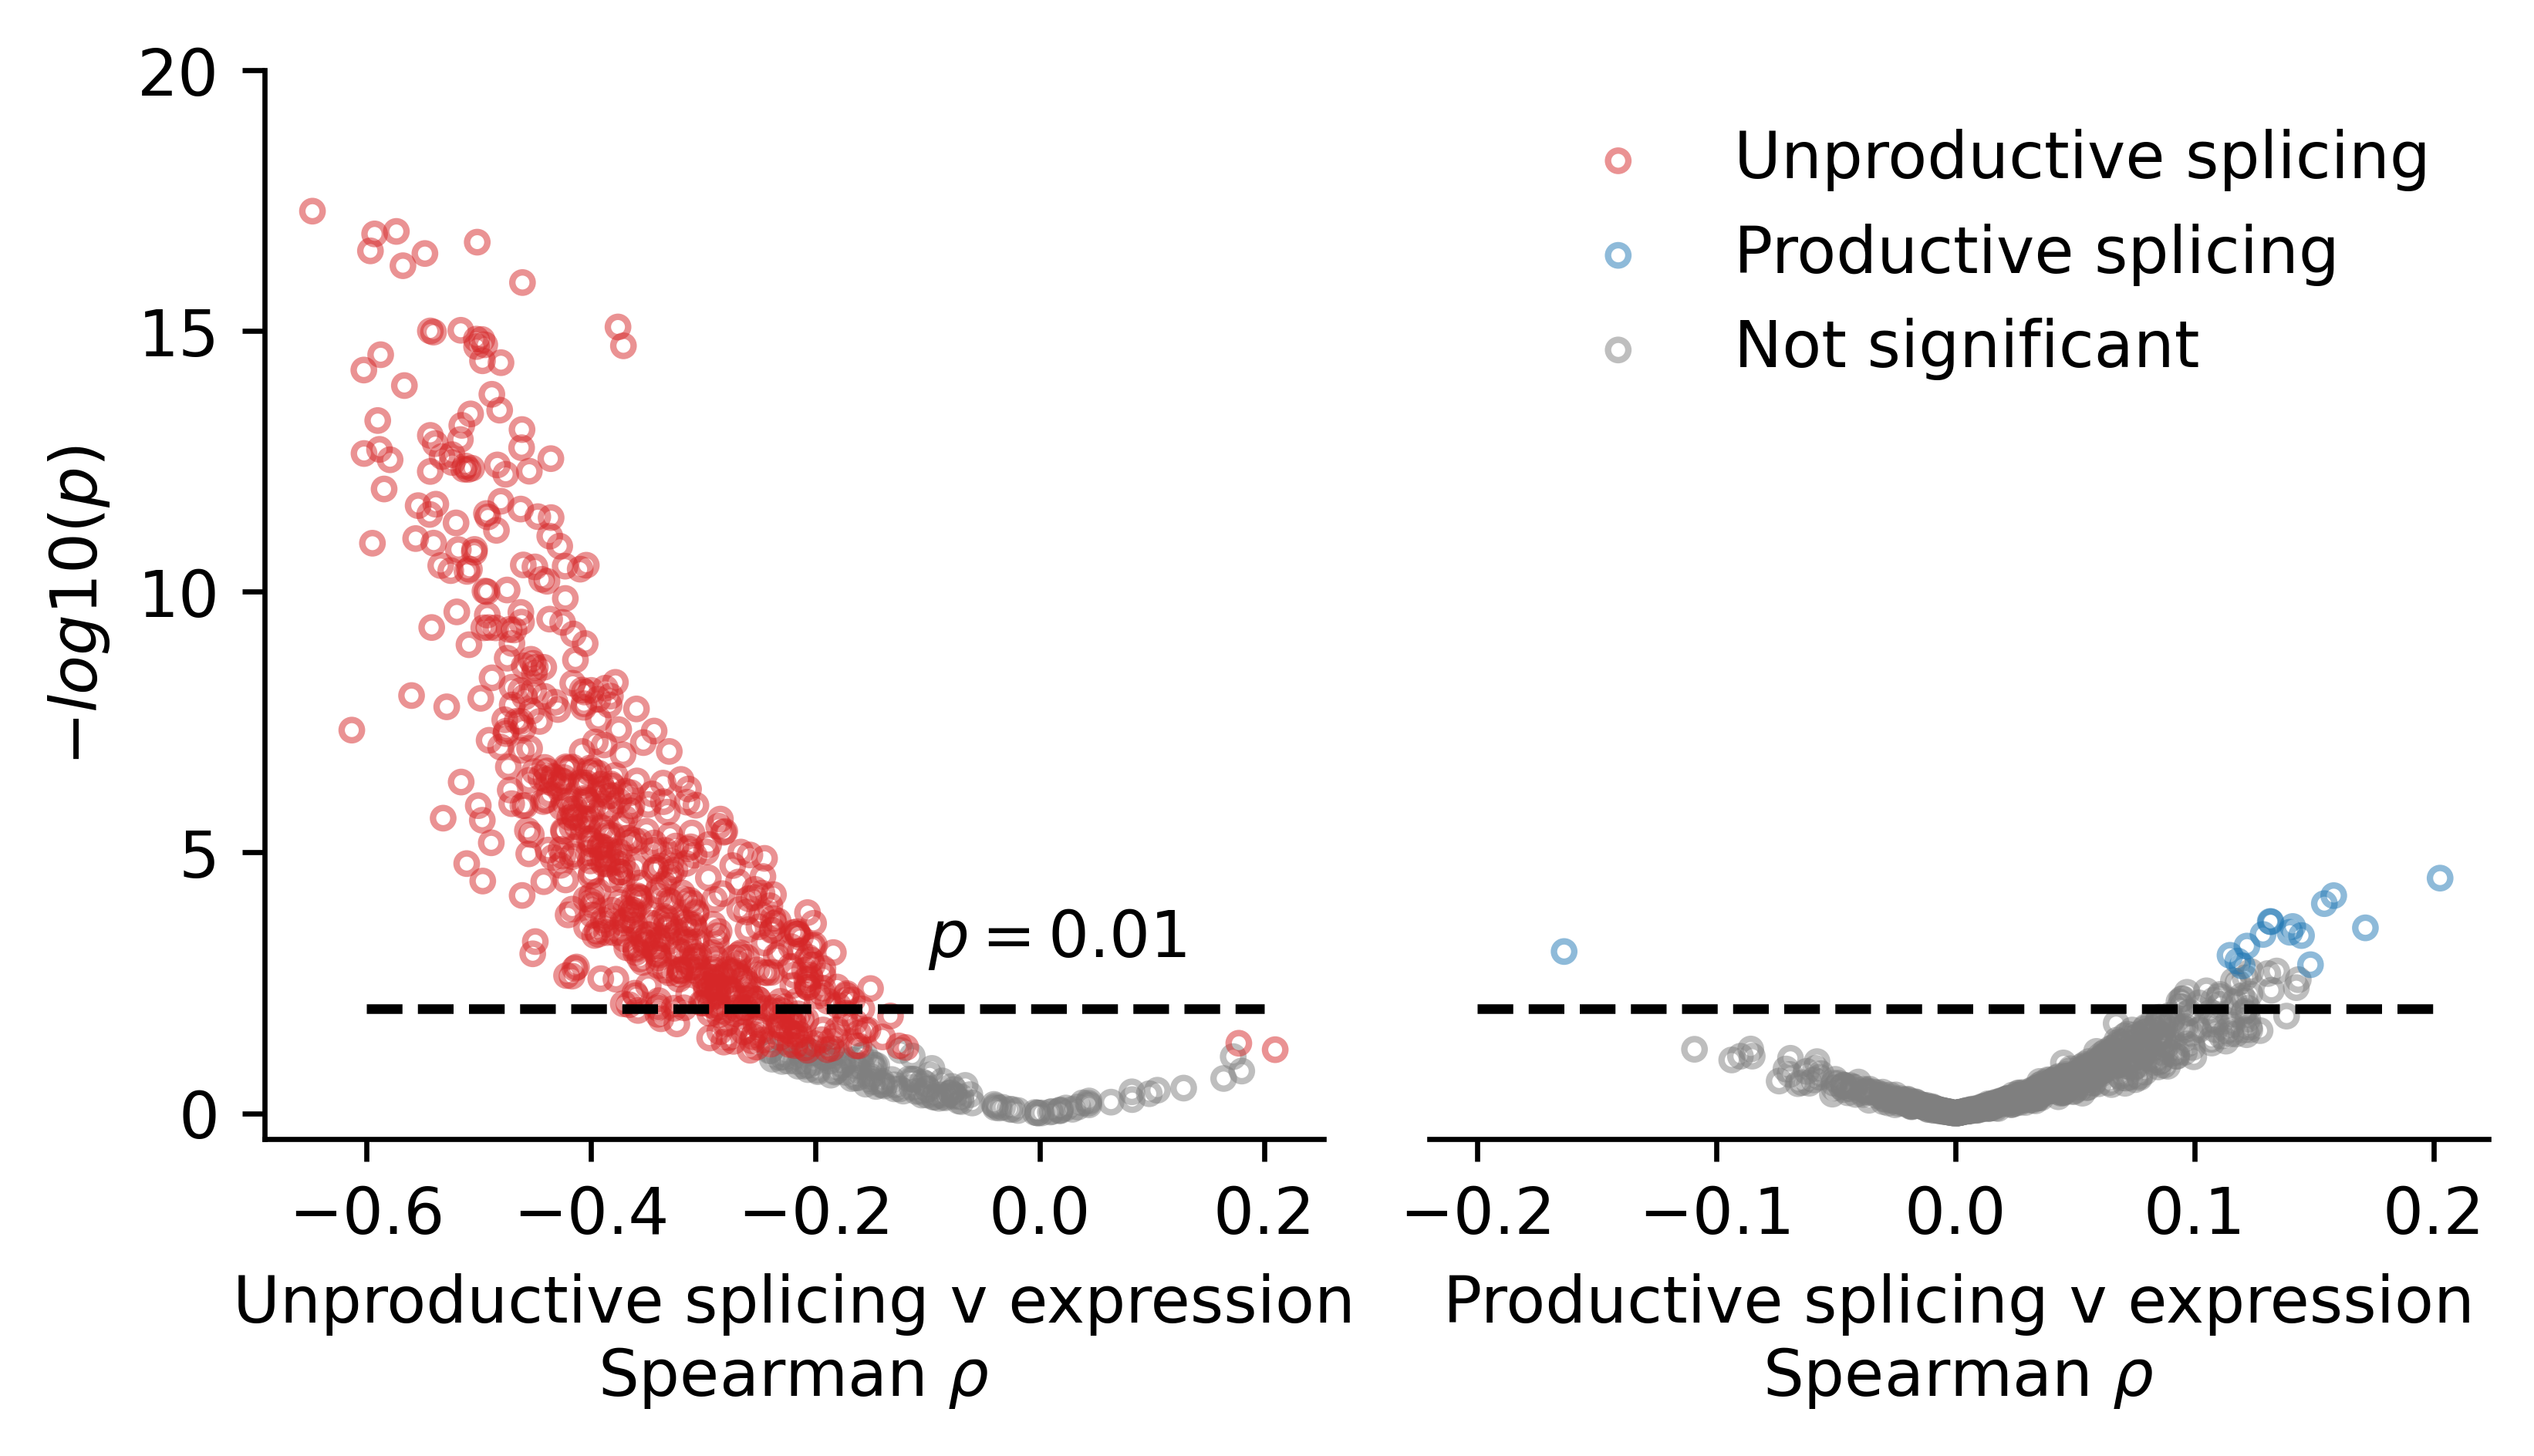

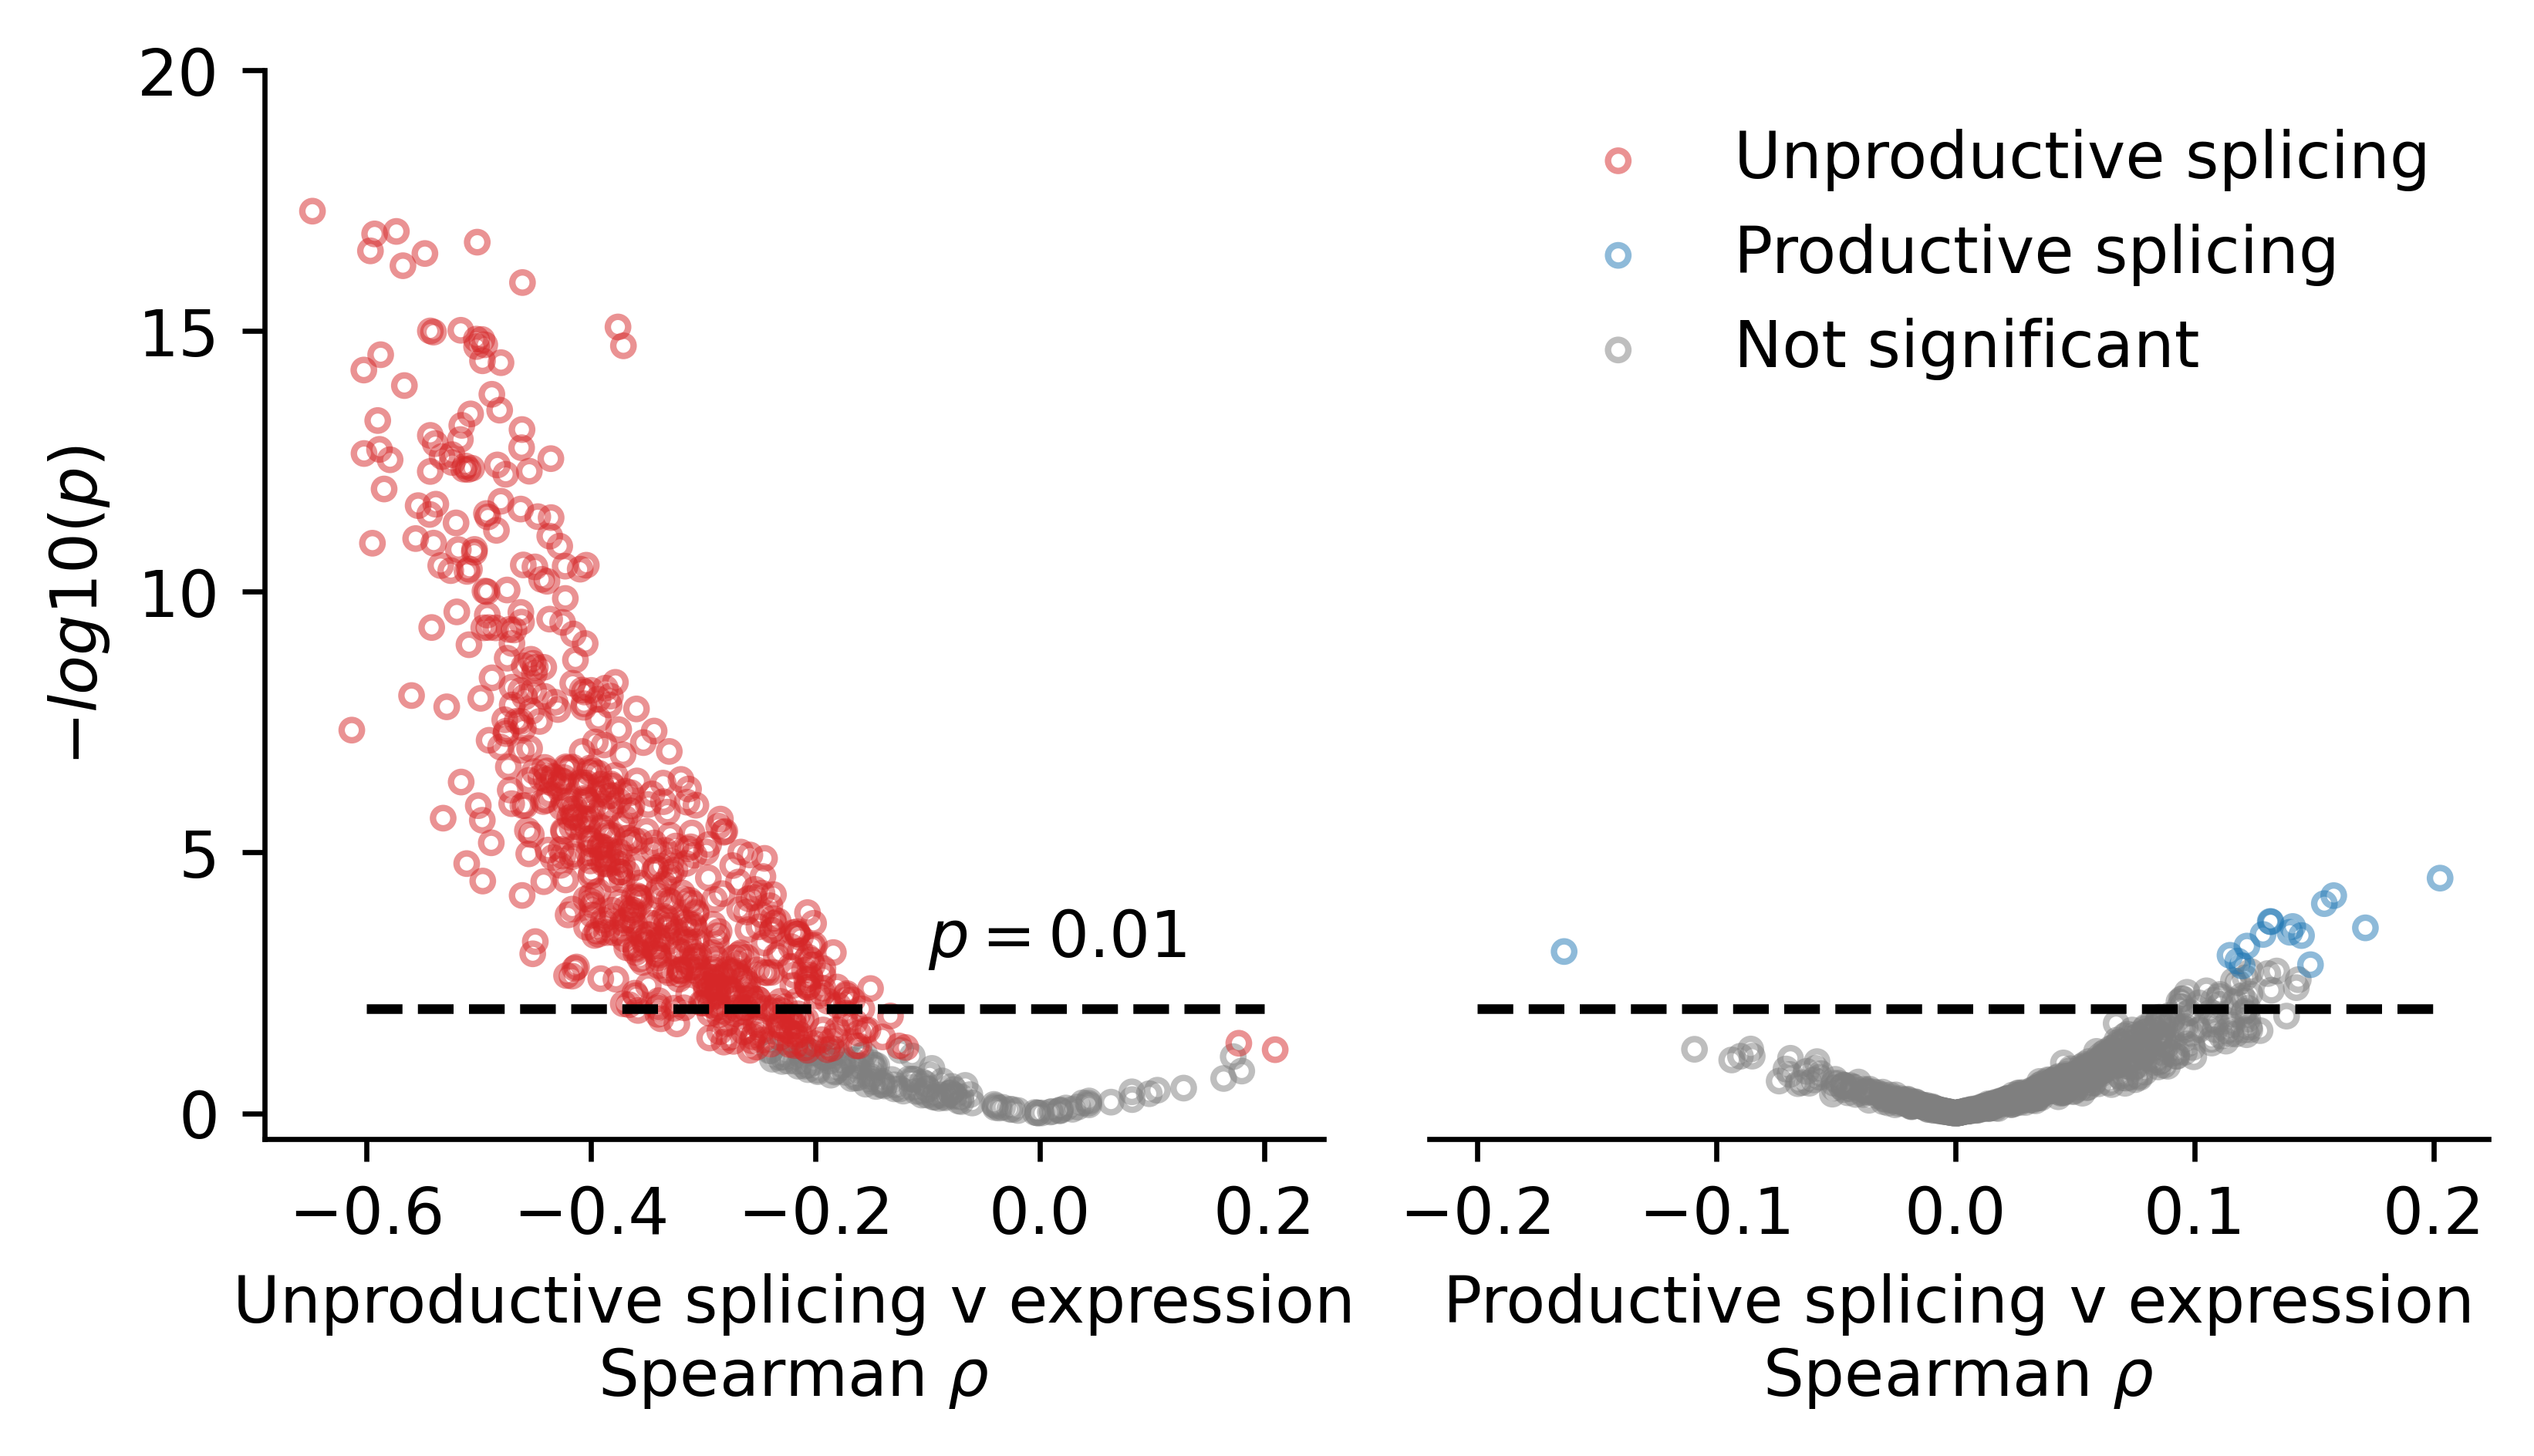

In [5]:
# Fig. 2b
# print(fig2b_legend(fig2b_source_data)) for the generated legend text.

plot_fig2b(fig2b_series)
save_panel('fig2b', dpi=600)

### Fig. 2e

Boxplots of *GABBR1* expression level across GTEx tissues. High expression of
*GABBR1* in brain tissue is associated with high exon inclusion. Each point is
one sample from a distinct GTEx donor, with n given below each box. Boxes depict
the median (red line) and interquartile range (IQR), with whiskers extending to
the most extreme value no greater than 1.5× IQR from the hinge, with all points
overlaid. P values shown are from a two-sided Wilcoxon signed-rank test on
per-donor medians of brain and non-brain tissues.

The caption quotes n = 340 paired donors — confirm against
`fig2e_boxplot_stats['wilcoxon']['n_pairs']` after running cell 3.

wrote plots/fig2e.[png|pdf|svg]


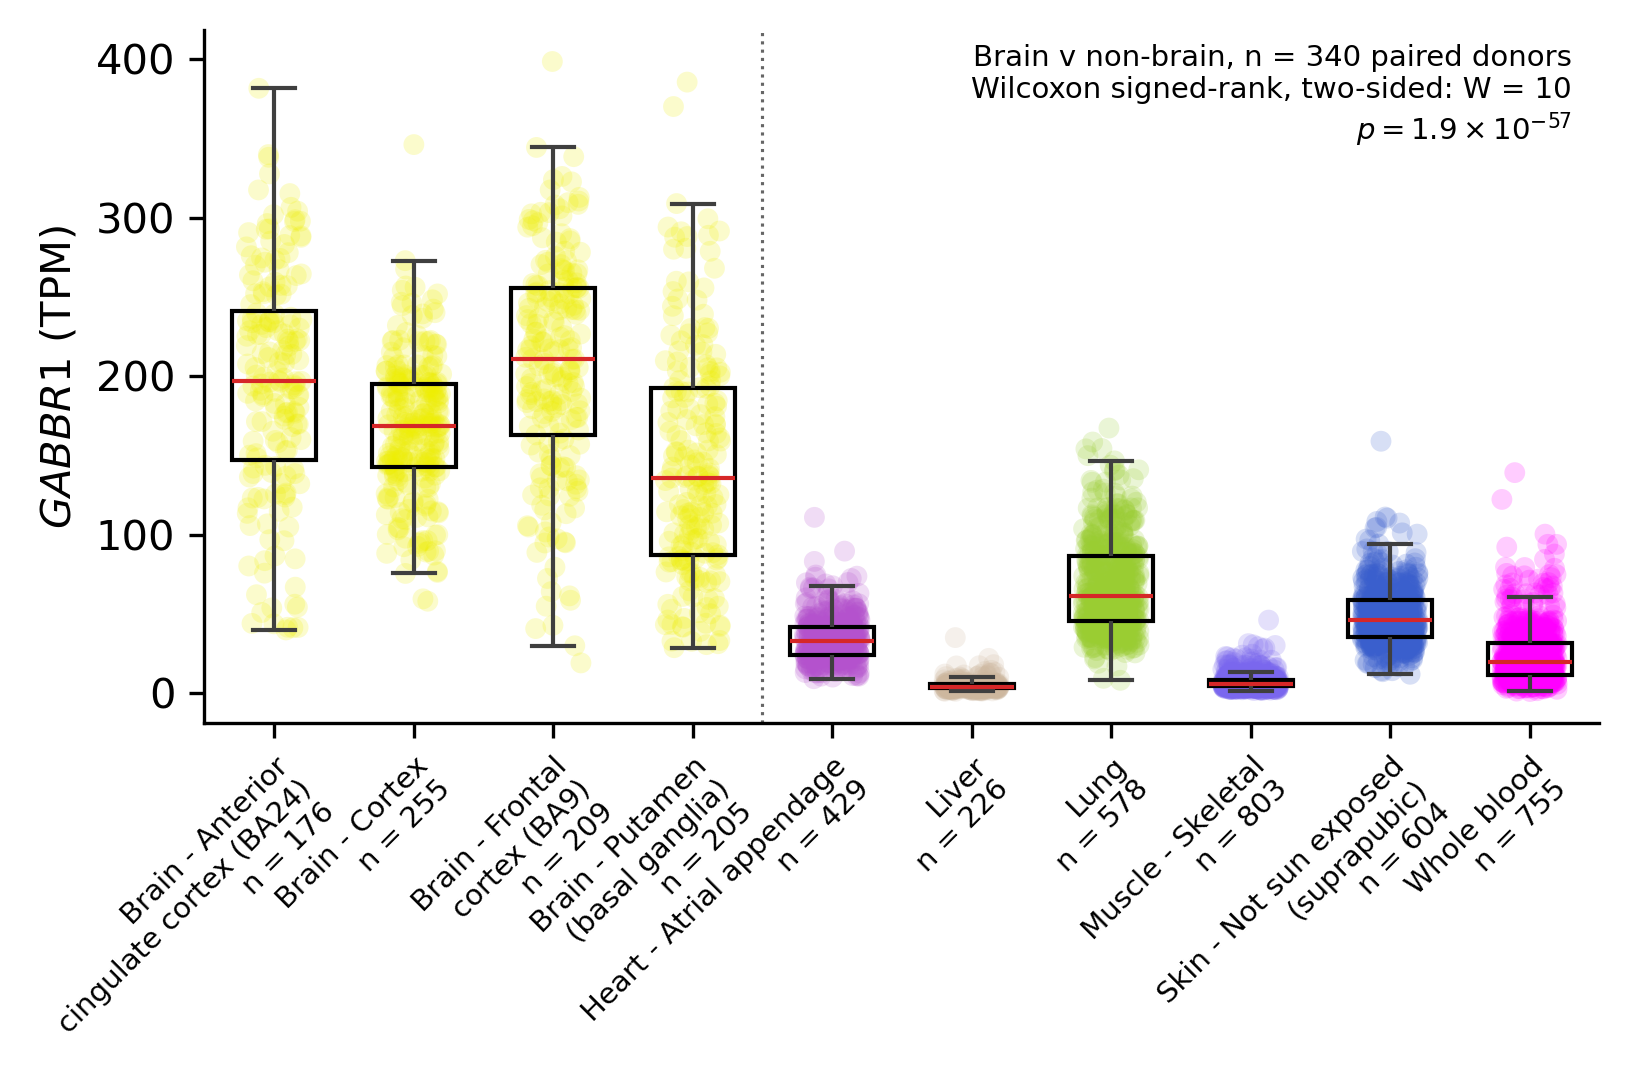

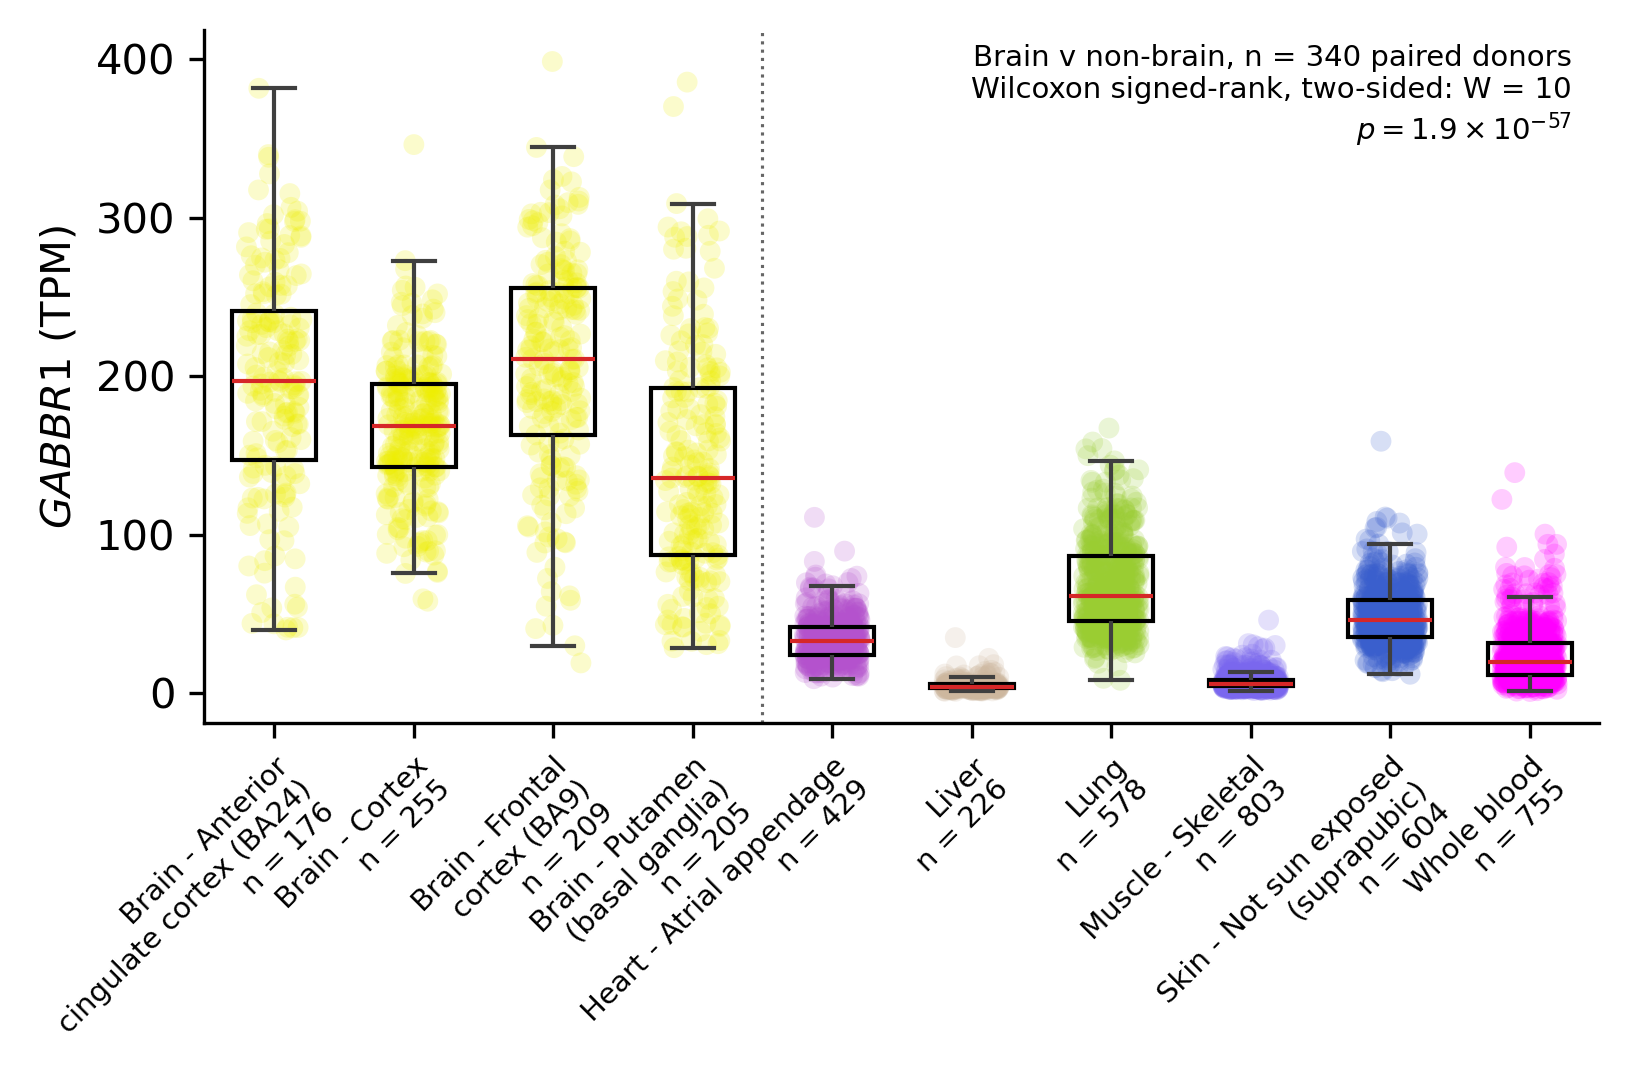

In [6]:
# Fig. 2e
# print(boxplot_legend(fig2e_boxplot_stats)) for the generated legend text.
# fig2e_boxplot_stats['wilcoxon']['n_pairs'] is the paired-donor n in the caption.

plot_gene_boxplots(fig2e_boxplot_df, 'GABBR1', TEN_TISSUES_CLEAN, BOXPLOT_PALETTE,
                   stats=fig2e_boxplot_stats)
save_panel('fig2e', dpi=300)